## Importar las Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuración para gráficos más nítidos
plt.rcParams["figure.figsize"] = (8, 5)
plt.style.use("ggplot")


# 1. Carga del dataset Ventas
Cargar los datos de ventas desde el archivo CSV.
Contiene información sobre las ventas de productos. Cada fila representa una venta y contiene varias columnas con los datos sobre las ventas.

In [2]:
ventas = pd.read_csv("ventas.csv", encoding = "UTF-8")

# 2. Inspección de los datos.
 El ejercicio pide mostrar una vista previa de las primeras 5 filas.

In [3]:
print("\n--- Visualización previa de las primeras 5 filas ---")
ventas.head()


--- Visualización previa de las primeras 5 filas ---


,ID_VENTA,FECHA,ID_CLIENTE,ID_PRODUCTO,PRODUCTO,CANTIDAD,PRECIO_UNITARIO,MEDIO_PAGO,TOTAL_VENTA
0,1001,2026-08-01,C001,P001,Notebook Lenovo,1,850000,Tarjeta,850000
1,1002,2026-08-01,C002,P003,Mouse inalámbrico,2,18500,Mercado Pago,37000
2,1003,2026-08-02,C003,P002,Monitor Samsung 24,1,220000,Tarjeta,220000
3,1004,2026-08-02,C001,P005,Teclado mecánico,1,72000,Transferencia,72000
4,1005,2026-08-03,C004,P004,Auriculares Bluetooth,2,45000,Tarjeta,90000


In [4]:
print("\n--- Información general ---")
ventas.info()


--- Información general ---
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID_VENTA         20 non-null     int64
 1   FECHA            20 non-null     str  
 2   ID_CLIENTE       20 non-null     str  
 3   ID_PRODUCTO      20 non-null     str  
 4   PRODUCTO         20 non-null     str  
 5   CANTIDAD         20 non-null     int64
 6   PRECIO_UNITARIO  20 non-null     int64
 7   MEDIO_PAGO       20 non-null     str  
 8   TOTAL_VENTA      20 non-null     int64
dtypes: int64(4), str(5)
memory usage: 2.4 KB


In [5]:
print("\n--- Estadísticas descriptivas — variables numéricas ---")
ventas.describe()
#print(ventas.describe())


--- Estadísticas descriptivas — variables numéricas ---


,ID_VENTA,CANTIDAD,PRECIO_UNITARIO,TOTAL_VENTA
count,20.00000,20.000000,20.000000,20.000000
mean,1010.50000,1.350000,227375.000000,242475.000000
std,5.91608,0.587143,282802.603418,275824.862196
min,1001.00000,1.000000,18500.000000,37000.000000
25%,1005.75000,1.000000,54750.000000,68500.000000
50%,1010.50000,1.000000,111000.000000,120500.000000
75%,1015.25000,2.000000,242500.000000,265000.000000
max,1020.00000,3.000000,850000.000000,850000.000000


# 3. Visualización Univariada

## Histogramas y Boxplots para observar la distribución y detectar posibles outliers.

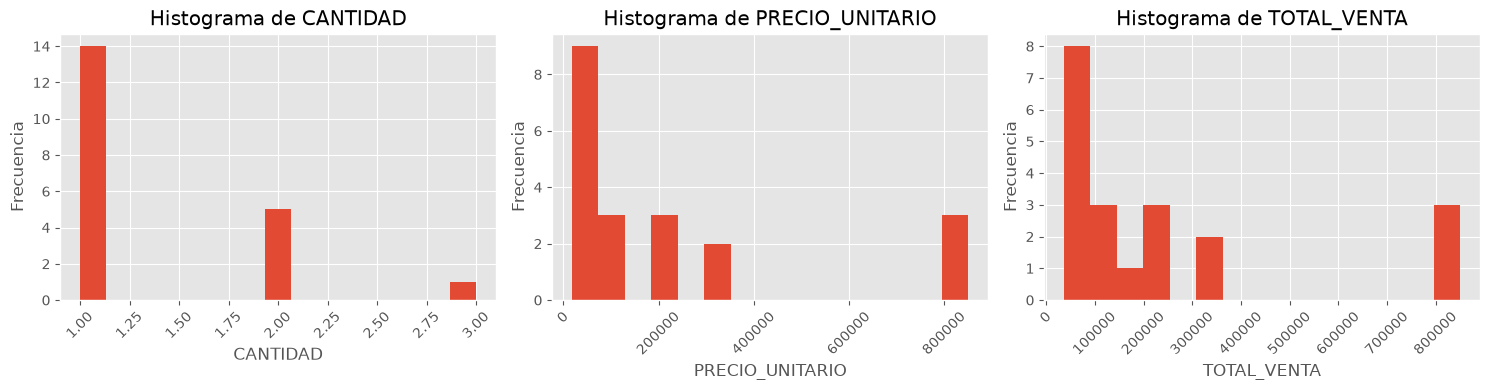

In [6]:
# Histograma
numericas = ["CANTIDAD", "PRECIO_UNITARIO", "TOTAL_VENTA"]

# Crear figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, columna in enumerate(numericas):
    ventas[columna].hist(bins=15, ax=axes[i], grid=True)
    axes[i].set_title(f"Histograma de {columna}")
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel("Frecuencia")

    # Rotar etiquetas del eje X para evitar solapamientos
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



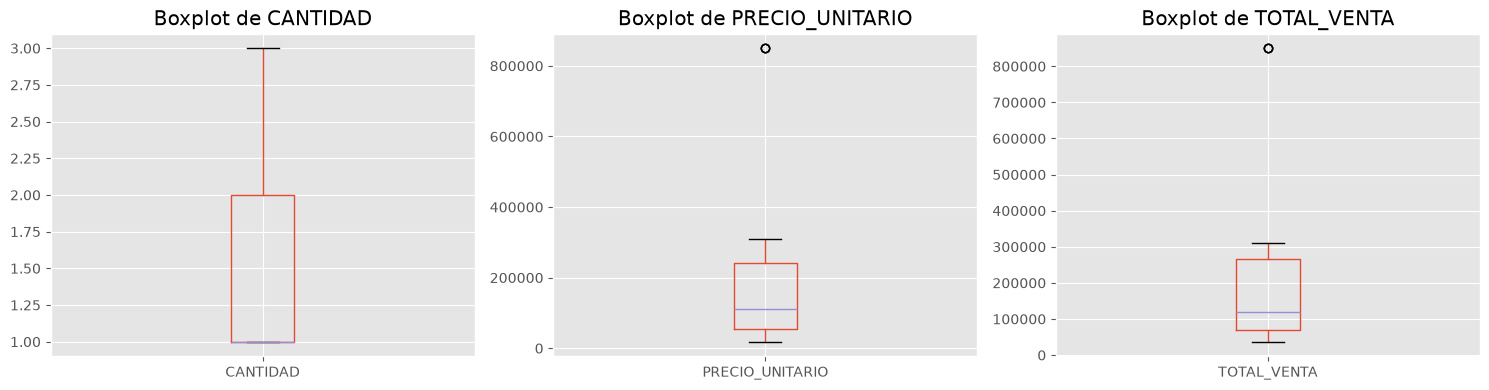

In [7]:
# Boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, columna in enumerate(numericas):
    ventas.boxplot(column=columna, ax=axes[i])
    axes[i].set_title(f"Boxplot de {columna}")

plt.tight_layout()
plt.show()

## Creación de diferentes tipos de gráficos, se busca identificar patrones, distribuciones, relaciones y posibles outliers en los datos.

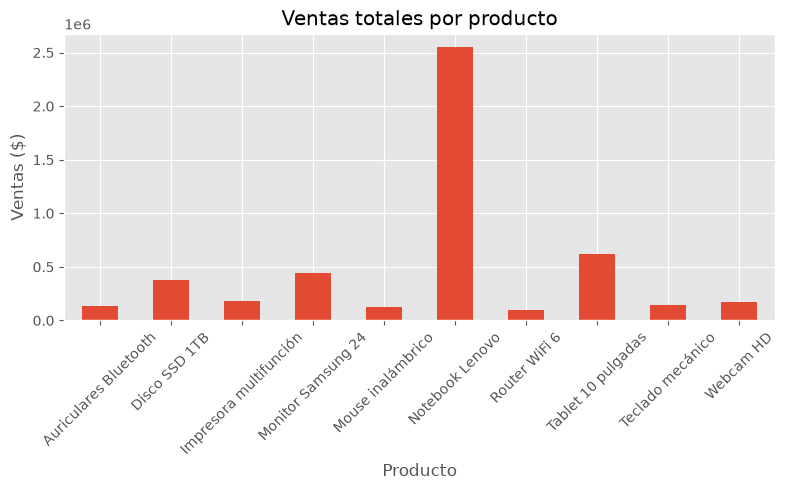

In [8]:
ventas_por_producto = ventas.groupby("PRODUCTO")["TOTAL_VENTA"].sum()

ventas_por_producto.plot(
    kind="bar",
)

plt.title("Ventas totales por producto")
plt.xlabel("Producto")
plt.ylabel("Ventas ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Gráfico 1 — Ventas por producto.
Permite identificar qué productos generan mayores ingresos.

### Gráfico 2 - Cantidad vendida.
Permite observar cuáles son los productos más vendidos en cantidad.

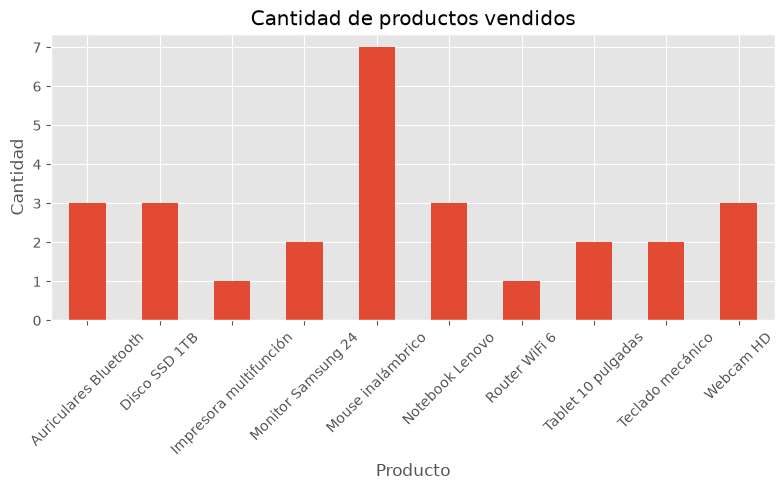

In [9]:
cantidad_por_producto = ventas.groupby("PRODUCTO")["CANTIDAD"].sum()

cantidad_por_producto.plot(
    kind="bar",
)

plt.title("Cantidad de productos vendidos")
plt.xlabel("Producto")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Gráfico 3 - Distribución de los precios.

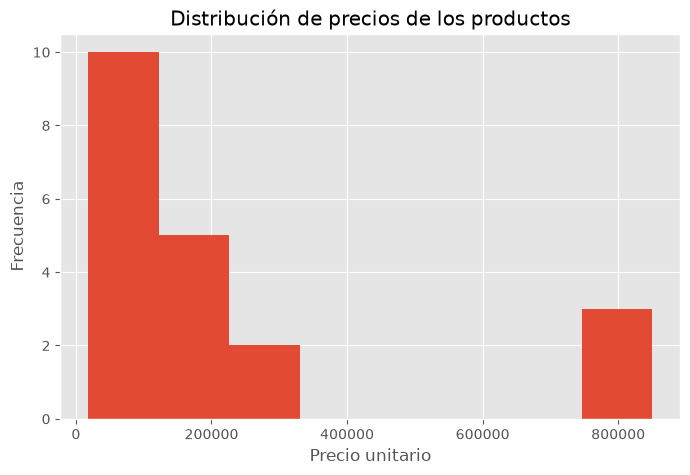

In [10]:
plt.hist(
    ventas["PRECIO_UNITARIO"],
    bins=8
)

plt.title("Distribución de precios de los productos")
plt.xlabel("Precio unitario")
plt.ylabel("Frecuencia")

plt.show()

# 4. Relaciones entre variables - Matriz de Correlación


--- Correlaciones ---
                 CANTIDAD  PRECIO_UNITARIO  TOTAL_VENTA
CANTIDAD         1.000000        -0.408773    -0.343294
PRECIO_UNITARIO -0.408773         1.000000     0.994068
TOTAL_VENTA     -0.343294         0.994068     1.000000


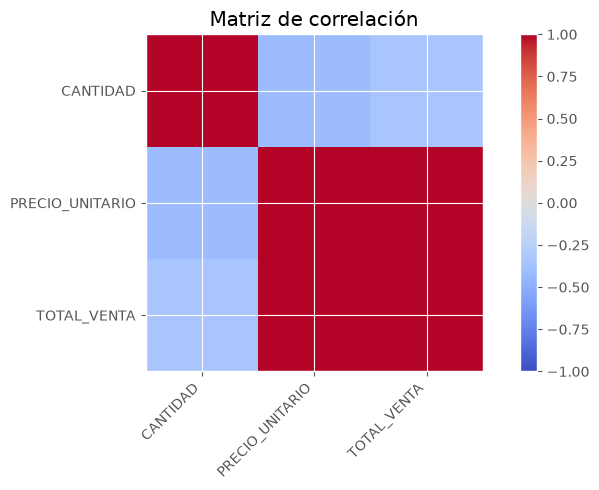

In [11]:
# Matriz de correlación
print("\n--- Correlaciones ---")
numericas = ['CANTIDAD', 'PRECIO_UNITARIO', 'TOTAL_VENTA']
corr = ventas[numericas].corr()
print(corr)

#plt.matshow(datos.corr(), cmap="coolwarm")
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

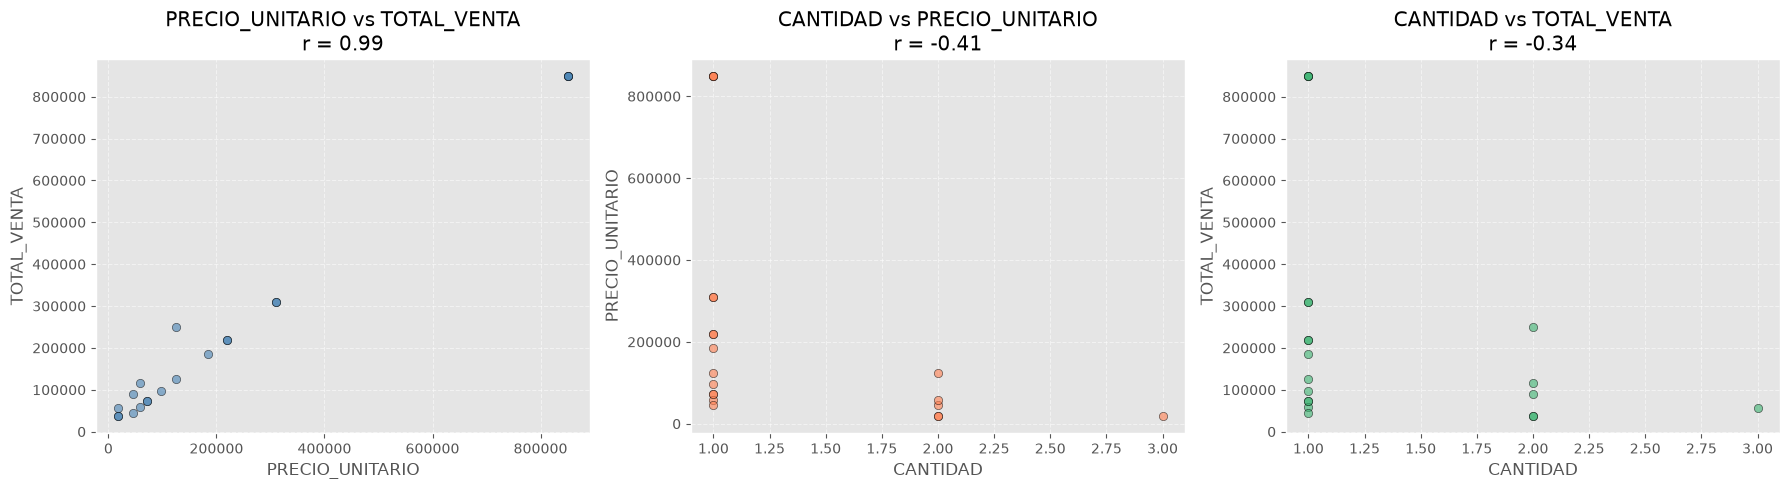

In [12]:
# Scatterplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pares = [
    ('PRECIO_UNITARIO', 'TOTAL_VENTA', 'steelblue'),
    ('CANTIDAD', 'PRECIO_UNITARIO', 'coral'),
    ('CANTIDAD', 'TOTAL_VENTA', 'mediumseagreen')
]

for ax, (x, y, color) in zip(axes, pares):
    ax.scatter(ventas[x], ventas[y], alpha=0.6, color=color, edgecolor='k')
    r = corr.loc[x, y]
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}\nr = {r:.2f}')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### El análisis de correlación muestra una relación positiva fuerte entre PRECIO_UNITARIO y TOTAL_VENTA (r = 0,99), indicando que los productos de mayor precio tienden a generar mayores valores de venta. 

# 5. Identificación de Outliers con regla IQR

In [13]:
Q1 = ventas["TOTAL_VENTA"].quantile(0.25)
Q3 = ventas["TOTAL_VENTA"].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 = {Q1}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")

outliers = ventas[(ventas["TOTAL_VENTA"] < Q1 - 1.5*IQR) | (ventas["TOTAL_VENTA"] > Q3 + 1.5*IQR)]

print(f"\nCantidad de outliers en Total_Venta: {len(outliers)}")
print(outliers)

Q1 = 68500.0
Q3 = 265000.0
IQR = 196500.0

Cantidad de outliers en Total_Venta: 3
    ID_VENTA       FECHA ID_CLIENTE ID_PRODUCTO         PRODUCTO  CANTIDAD  \
0       1001  2026-08-01       C001        P001  Notebook Lenovo         1   
5       1006  2026-08-03       C005        P001  Notebook Lenovo         1   
18      1019  2026-08-10       C009        P001  Notebook Lenovo         1   

    PRECIO_UNITARIO     MEDIO_PAGO  TOTAL_VENTA  
0            850000        Tarjeta       850000  
5            850000        Tarjeta       850000  
18           850000  Transferencia       850000  


In [14]:
print (ventas)

    ID_VENTA       FECHA ID_CLIENTE ID_PRODUCTO                PRODUCTO  \
0       1001  2026-08-01       C001        P001         Notebook Lenovo   
1       1002  2026-08-01       C002        P003       Mouse inalámbrico   
2       1003  2026-08-02       C003        P002      Monitor Samsung 24   
3       1004  2026-08-02       C001        P005        Teclado mecánico   
4       1005  2026-08-03       C004        P004   Auriculares Bluetooth   
5       1006  2026-08-03       C005        P001         Notebook Lenovo   
6       1007  2026-08-04       C006        P006               Webcam HD   
7       1008  2026-08-04       C007        P003       Mouse inalámbrico   
8       1009  2026-08-05       C008        P007           Disco SSD 1TB   
9       1010  2026-08-05       C002        P005        Teclado mecánico   
10      1011  2026-08-06       C009        P008      Tablet 10 pulgadas   
11      1012  2026-08-06       C010        P004   Auriculares Bluetooth   
12      1013  2026-08-07 